# 4주차. Transformer

In [1]:
%pip install -q torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 데이터

In [2]:
# 2, 3주차와 같은 실제 번역 데이터를 다시 받는다 (Tatoeba, CC-BY 2.0, manythings.org/anki)
import re
import urllib.request
import zipfile
import io

url = "https://www.manythings.org/anki/kor-eng.zip"
req = urllib.request.Request(url, headers={
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept": "*/*",
})
raw = urllib.request.urlopen(req, timeout=30).read()

with zipfile.ZipFile(io.BytesIO(raw)) as zf:
    text = zf.read("kor.txt").decode("utf-8")

lines = text.strip().split("\n")
pairs = [(line.split("\t")[0], line.split("\t")[1]) for line in lines]
print(f"전체 문장 쌍: {len(pairs)}개")


전체 문장 쌍: 6394개


In [3]:
# 영어는 단어 단위, 한국어는 음절 단위(공백 포함)로 쪼갠다
def tok_en(s):
    return re.findall(r"[a-z']+|[.!?]", s.lower())


filtered = []
for en, ko in pairs:
    en_toks = tok_en(en)
    ko_chars = list(ko)
    if 2 <= len(en_toks) <= 8 and 2 <= len(ko_chars) <= 14:
        filtered.append((en, ko, en_toks, ko_chars))

print(f"필터 후: {len(filtered)}개")


필터 후: 3211개


In [4]:
# 어휘를 만들고 train/val/test로 나눈다 (3주차와 동일한 분리 기준)
import collections
import random
import torch
import torch.nn as nn
import math

random.seed(0)
torch.manual_seed(0)
random.shuffle(filtered)

PAD, SOS, EOS, UNK = 0, 1, 2, 3


def build_vocab(seqs):
    counter = collections.Counter(t for s in seqs for t in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, _ in counter.most_common()]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos


en_stoi, en_itos = build_vocab([e for _, _, e, _ in filtered])
ko_stoi, ko_itos = build_vocab([k for _, _, _, k in filtered])
print(f"영어 어휘: {len(en_itos)}개, 한국어 어휘: {len(ko_itos)}개")


def encode(seq, stoi, add_eos):
    ids = [stoi.get(t, UNK) for t in seq]
    if add_eos:
        ids = ids + [EOS]
    return torch.tensor(ids, dtype=torch.long)


pair_data = [(encode(e, en_stoi, False), encode(k, ko_stoi, True)) for _, _, e, k in filtered]
n_val, n_test = 300, 300
val_pairs = pair_data[:n_val]
test_pairs = pair_data[n_val:n_val + n_test]
train_pairs = pair_data[n_val + n_test:]
print(f"train {len(train_pairs)}개 | val {len(val_pairs)}개 | test {len(test_pairs)}개")


영어 어휘: 1976개, 한국어 어휘: 833개
train 2611개 | val 300개 | test 300개


## Self-Attention은 순서를 모른다

In [5]:
# 두 토큰의 순서만 바꿔서 넣어도, 움직이지 않은 세 번째 토큰의 출력이 똑같이 나오는지 확인한다
d_model = 8

emb_demo = nn.Embedding(10, d_model)
Wq_demo = nn.Linear(d_model, d_model, bias=False)
Wk_demo = nn.Linear(d_model, d_model, bias=False)
Wv_demo = nn.Linear(d_model, d_model, bias=False)


def self_attention(x):
    Q, K, V = Wq_demo(x), Wk_demo(x), Wv_demo(x)
    scores = Q @ K.transpose(-1, -2) / (d_model ** 0.5)
    attn = torch.softmax(scores, dim=-1)
    return attn @ V


x = emb_demo(torch.tensor([3, 7, 1]))            # 원래 순서: 3, 7, 1
x_shuffled = emb_demo(torch.tensor([7, 3, 1]))    # 앞 두 개만 순서를 바꿈. 1은 그대로 3번째

out = self_attention(x)
out_shuffled = self_attention(x_shuffled)

print("셋째 토큰(1) 출력, 원래 순서:  ", out[2][:4].tolist())
print("셋째 토큰(1) 출력, 순서 바꿈:  ", out_shuffled[2][:4].tolist())
print("두 출력이 완전히 같은가:", torch.allclose(out[2], out_shuffled[2], atol=1e-6))


셋째 토큰(1) 출력, 원래 순서:   [-0.13235750794410706, 0.27191510796546936, -0.6247336864471436, -0.6808044910430908]
셋째 토큰(1) 출력, 순서 바꿈:   [-0.13235750794410706, 0.27191510796546936, -0.6247336864471436, -0.6808044910430908]
두 출력이 완전히 같은가: True


## 포지셔널 인코딩 (Positional Encoding)

In [6]:
# 위치마다 다른 sin·cos 벡터를 만든다
def positional_encoding(max_len, d):
    pe = torch.zeros(max_len, d)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe


PE_demo = positional_encoding(6, d_model)
for i in range(4):
    print(f"위치 {i} PE: {PE_demo[i].round(decimals=2).tolist()}")


위치 0 PE: [0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
위치 1 PE: [0.8399999737739563, 0.5400000214576721, 0.10000000149011612, 1.0, 0.009999999776482582, 1.0, 0.0, 1.0]
위치 2 PE: [0.9100000262260437, -0.41999998688697815, 0.20000000298023224, 0.9800000190734863, 0.019999999552965164, 1.0, 0.0, 1.0]
위치 3 PE: [0.14000000059604645, -0.9900000095367432, 0.30000001192092896, 0.9599999785423279, 0.029999999329447746, 1.0, 0.0, 1.0]


In [7]:
# 이번엔 임베딩에 PE를 더한 다음 같은 실험을 반복한다
x_pe = emb_demo(torch.tensor([3, 7, 1])) + PE_demo[:3]
x_shuffled_pe = emb_demo(torch.tensor([7, 3, 1])) + PE_demo[:3]

out_pe = self_attention(x_pe)
out_shuffled_pe = self_attention(x_shuffled_pe)

print("셋째 토큰(1) 출력, 원래 순서:  ", out_pe[2][:4].tolist())
print("셋째 토큰(1) 출력, 순서 바꿈:  ", out_shuffled_pe[2][:4].tolist())
print("두 출력이 완전히 같은가:", torch.allclose(out_pe[2], out_shuffled_pe[2], atol=1e-6))


셋째 토큰(1) 출력, 원래 순서:   [-0.14342562854290009, 0.19872812926769257, -0.5702119469642639, -0.8344651460647583]
셋째 토큰(1) 출력, 순서 바꿈:   [-0.11058516055345535, 0.15087448060512543, -0.7087870240211487, -0.8669885396957397]
두 출력이 완전히 같은가: False


## 멀티헤드 어텐션 (Multi-Head Attention)

In [8]:
# Q, K, V를 head 수만큼 쪼개서 각자 다른 attention을 계산한다
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.h = n_heads
        self.dk = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, q_in, k_in, v_in, mask=None):
        B, Sq, _ = q_in.shape
        Sk = k_in.shape[1]
        Q = self.W_Q(q_in).view(B, Sq, self.h, self.dk).transpose(1, 2)
        K = self.W_K(k_in).view(B, Sk, self.h, self.dk).transpose(1, 2)
        V = self.W_V(v_in).view(B, Sk, self.h, self.dk).transpose(1, 2)
        scores = Q @ K.transpose(-1, -2) / (self.dk ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(scores, dim=-1)
        out = alpha @ V
        out = out.transpose(1, 2).contiguous().view(B, Sq, self.h * self.dk)
        return self.W_O(out), alpha


In [9]:
# head마다 attention weight가 실제로 다르게 나오는지 확인한다
torch.manual_seed(0)
mha_demo = MultiHeadAttention(d_model=8, n_heads=4)

toy = emb_demo(torch.tensor([[3, 7, 1, 5]])) + PE_demo[:4]  # (1, 4, 8)
_, alpha = mha_demo(toy, toy, toy)

for head in range(4):
    row = alpha[0, head, 1]  # 1번 토큰이 나머지를 보는 가중치
    print(f"head {head} | 1번 토큰의 가중치: {row.tolist()}")


head 0 | 1번 토큰의 가중치: [0.2559186816215515, 0.05926080420613289, 0.3495141863822937, 0.3353063762187958]
head 1 | 1번 토큰의 가중치: [0.10949231684207916, 0.6872528195381165, 0.14954493939876556, 0.05370992049574852]
head 2 | 1번 토큰의 가중치: [0.14901132881641388, 0.5442782640457153, 0.21189047396183014, 0.09482000768184662]
head 3 | 1번 토큰의 가중치: [0.1956244856119156, 0.3641721308231354, 0.07484959065914154, 0.3653537929058075]


## 인코더·디코더 블록으로 미니 Transformer 조립

In [10]:
# FFN, 인코더 블록, 디코더 블록을 정의한다
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))

    def forward(self, x):
        return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        a, _ = self.mha(x, x, x, mask)          # Self-Attention
        x = self.ln1(x + a)                      # 잔차 연결
        f = self.ffn(x)
        x = self.ln2(x + f)                       # 잔차 연결
        return x


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.self_mha = MultiHeadAttention(d_model, n_heads)
        self.cross_mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, x, enc_out, self_mask, cross_mask):
        a, _ = self.self_mha(x, x, x, self_mask)       # Masked Self-Attention
        x = self.ln1(x + a)
        c, alpha = self.cross_mha(x, enc_out, enc_out, cross_mask)  # Cross-Attention
        x = self.ln2(x + c)
        f = self.ffn(x)
        x = self.ln3(x + f)
        return x, alpha


In [11]:
# 인코더 하나, 디코더 하나로 이루어진 미니 Transformer
D_MODEL, N_HEADS, D_FF = 128, 4, 256
PE = positional_encoding(50, D_MODEL)


class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.en_emb = nn.Embedding(len(en_itos), D_MODEL, padding_idx=PAD)
        self.ko_emb = nn.Embedding(len(ko_itos), D_MODEL, padding_idx=PAD)
        self.encoder = EncoderBlock(D_MODEL, N_HEADS, D_FF)
        self.decoder = DecoderBlock(D_MODEL, N_HEADS, D_FF)
        self.output_layer = nn.Linear(D_MODEL, len(ko_itos))

    def forward(self, src, tgt_in, src_pad_mask, tgt_pad_mask):
        s_len, t_len = src.shape[1], tgt_in.shape[1]

        src_x = self.en_emb(src) + PE[:s_len].unsqueeze(0)
        enc_mask = src_pad_mask[:, None, None, :]
        enc_out = self.encoder(src_x, enc_mask)

        tgt_x = self.ko_emb(tgt_in) + PE[:t_len].unsqueeze(0)
        causal = torch.tril(torch.ones(t_len, t_len)).bool()[None, None]      # 미래 위치 마스킹
        self_mask = causal & tgt_pad_mask[:, None, None, :]
        cross_mask = src_pad_mask[:, None, None, :]
        dec_out, alpha = self.decoder(tgt_x, enc_out, self_mask, cross_mask)

        return self.output_layer(dec_out), alpha


### 학습

epoch  0 | train loss 4.493 acc 0.27 | val loss 3.691 acc 0.36


epoch  5 | train loss 2.221 acc 0.55 | val loss 2.536 acc 0.51


epoch 10 | train loss 1.135 acc 0.75 | val loss 2.404 acc 0.55


epoch 15 | train loss 0.433 acc 0.91 | val loss 2.636 acc 0.57


epoch 20 | train loss 0.158 acc 0.97 | val loss 2.948 acc 0.56


epoch 25 | train loss 0.096 acc 0.98 | val loss 3.106 acc 0.57


epoch 30 | train loss 0.075 acc 0.98 | val loss 3.314 acc 0.57


epoch 35 | train loss 0.071 acc 0.98 | val loss 3.369 acc 0.57


epoch 39 | train loss 0.067 acc 0.98 | val loss 3.423 acc 0.57
학습 시간: 56.0초


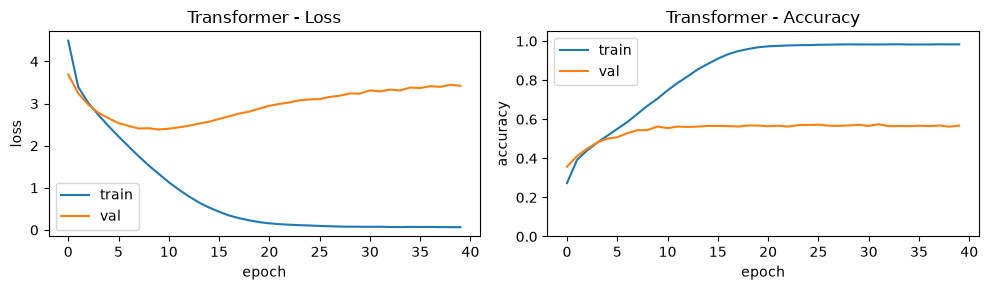

Transformer TEST 정확도 0.57


In [12]:
# 배치를 만들고 학습한다. teacher forcing이라 모든 디코더 시점을 한 번에 병렬로 계산한다
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt

model = MiniTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)


def make_batch(items):
    src = [s for s, _ in items]
    tgt = [t for _, t in items]
    src_pad = pad_sequence(src, batch_first=True, padding_value=PAD)
    tgt_pad = pad_sequence(tgt, batch_first=True, padding_value=PAD)
    sos_col = torch.full((len(tgt), 1), SOS, dtype=torch.long)
    tgt_in = torch.cat([sos_col, tgt_pad[:, :-1]], dim=1)
    return src_pad, tgt_in, tgt_pad, (src_pad != PAD), (tgt_in != PAD)


def run_epoch(dataset, train, bs=64):
    if train:
        random.shuffle(dataset)
    total_loss, total_tok, correct = 0, 0, 0
    for i in range(0, len(dataset), bs):
        batch = dataset[i:i + bs]
        src, tgt_in, tgt_out, src_mask, tgt_mask = make_batch(batch)
        if train:
            optimizer.zero_grad()
        logits, _ = model(src, tgt_in, src_mask, tgt_mask)
        loss = criterion(logits.reshape(-1, len(ko_itos)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            optimizer.step()
        mask = tgt_out != PAD
        correct += ((logits.argmax(-1) == tgt_out) & mask).sum().item()
        total_tok += mask.sum().item()
        total_loss += loss.item() * mask.sum().item()
    return total_loss / total_tok, correct / total_tok


import time
history = []
t0 = time.time()
for epoch in range(40):
    train_loss, train_acc = run_epoch(train_pairs, train=True)
    val_loss, val_acc = run_epoch(val_pairs, train=False)
    history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    if epoch % 5 == 0 or epoch == 39:
        print(f"epoch {epoch:>2} | train loss {train_loss:.3f} acc {train_acc:.2f} "
              f"| val loss {val_loss:.3f} acc {val_acc:.2f}")
transformer_train_time = time.time() - t0
print(f"학습 시간: {transformer_train_time:.1f}초")

epochs_, tl, ta, vl, va = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(epochs_, tl, label="train")
axes[0].plot(epochs_, vl, label="val")
axes[0].set_title("Transformer - Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[1].plot(epochs_, ta, label="train")
axes[1].plot(epochs_, va, label="val")
axes[1].set_title("Transformer - Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()

transformer_test_loss, transformer_test_acc = run_epoch(test_pairs, train=False)
print(f"Transformer TEST 정확도 {transformer_test_acc:.2f}")


### 추론

In [13]:
# 한 스텝씩 생성하면서, Cross-Attention이 매 스텝 인코더의 어느 위치를 가장 많이 보는지 확인한다
@torch.no_grad()
def translate(en_toks, max_len=15):
    src = encode(en_toks, en_stoi, add_eos=False).unsqueeze(0)
    src_mask = (src != PAD)[:, None, None, :]
    s_len = src.shape[1]
    src_x = model.en_emb(src) + PE[:s_len].unsqueeze(0)
    enc_out = model.encoder(src_x, src_mask)

    ys = [SOS]
    attn_rows = []
    for _ in range(max_len):
        tgt_in = torch.tensor([ys])
        t_len = tgt_in.shape[1]
        tgt_x = model.ko_emb(tgt_in) + PE[:t_len].unsqueeze(0)
        causal = torch.tril(torch.ones(t_len, t_len)).bool()[None, None]
        dec_out, alpha = model.decoder(tgt_x, enc_out, causal, src_mask)
        logits = model.output_layer(dec_out)
        nxt = logits[0, -1].argmax(-1).item()
        attn_rows.append(alpha[0, :, -1, :].mean(0).tolist())  # head 평균
        if nxt == EOS:
            break
        ys.append(nxt)
    return ys[1:], attn_rows


for en, ko, en_toks, _ in filtered[n_val:n_val + 4]:
    pred_ids, attn_rows = translate(en_toks)
    pred = "".join(ko_itos[i] for i in pred_ids)
    print(f"EN {en}")
    print(f"정답 {ko}")
    print(f"예측 {pred}")
    for step, tok_id in enumerate(pred_ids):
        row = attn_rows[step]
        best = max(range(len(en_toks)), key=lambda i: row[i])
        print(f"  step{step + 1} '{ko_itos[tok_id]}' -> 가장 많이 본 입력 단어: {en_toks[best]} ({row[best]:.2f})")
    print()


EN I'll speak with the teacher.
정답 선생님과 이야기하겠습니다.
예측 오늘에 가방이 바한다.
  step1 '오' -> 가장 많이 본 입력 단어: teacher (0.60)
  step2 '늘' -> 가장 많이 본 입력 단어: teacher (0.30)
  step3 '에' -> 가장 많이 본 입력 단어: with (0.32)
  step4 ' ' -> 가장 많이 본 입력 단어: with (0.43)
  step5 '가' -> 가장 많이 본 입력 단어: i'll (0.33)
  step6 '방' -> 가장 많이 본 입력 단어: with (0.31)
  step7 '이' -> 가장 많이 본 입력 단어: speak (0.25)
  step8 ' ' -> 가장 많이 본 입력 단어: with (0.35)
  step9 '바' -> 가장 많이 본 입력 단어: i'll (0.52)
  step10 '한' -> 가장 많이 본 입력 단어: i'll (0.26)
  step11 '다' -> 가장 많이 본 입력 단어: . (0.58)
  step12 '.' -> 가장 많이 본 입력 단어: . (0.48)

EN That made me nervous.
정답 저게 불안하게 만드네.
예측 저걸와 날라고 싶어.
  step1 '저' -> 가장 많이 본 입력 단어: that (0.38)
  step2 '걸' -> 가장 많이 본 입력 단어: me (0.47)
  step3 '와' -> 가장 많이 본 입력 단어: me (0.39)
  step4 ' ' -> 가장 많이 본 입력 단어: nervous (0.51)
  step5 '날' -> 가장 많이 본 입력 단어: me (0.48)
  step6 '라' -> 가장 많이 본 입력 단어: nervous (0.47)
  step7 '고' -> 가장 많이 본 입력 단어: nervous (0.41)
  step8 ' ' -> 가장 많이 본 입력 단어: nervous (0.46)
  step9 '싶' -> 가장 많이 본 입력 단

## 3주차 RNN+Attention과 비교

In [14]:
# 3주차의 RNN + Attention을 같은 데이터로 다시 학습시켜, 정확도와 학습 시간을 나란히 잰다
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

rnn_en_emb = nn.Embedding(len(en_itos), 64, padding_idx=PAD)
rnn_ko_emb = nn.Embedding(len(ko_itos), 64, padding_idx=PAD)
rnn_encoder = nn.LSTM(64, 128, batch_first=True)


class RNNAttnDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(64, 128, batch_first=True)
        self.W_Q = nn.Linear(128, 128, bias=False)
        self.W_K = nn.Linear(128, 128, bias=False)
        self.W_V = nn.Linear(128, 128, bias=False)
        self.out = nn.Linear(128 * 2, len(ko_itos))

    def forward(self, tgt_in, h0c0, enc_out, src_mask):
        dec_out, hc = self.rnn(rnn_ko_emb(tgt_in), h0c0)
        Q, K, V = self.W_Q(dec_out), self.W_K(enc_out), self.W_V(enc_out)
        scores = Q @ K.transpose(-1, -2) / (128 ** 0.5)
        scores = scores.masked_fill(~src_mask.unsqueeze(1), float("-inf"))
        alpha = torch.softmax(scores, dim=-1)
        context = alpha @ V
        logits = self.out(torch.cat([dec_out, context], dim=-1))
        return logits, alpha, hc


rnn_decoder = RNNAttnDecoder()
rnn_params = list(rnn_en_emb.parameters()) + list(rnn_ko_emb.parameters()) \
    + list(rnn_encoder.parameters()) + list(rnn_decoder.parameters())
rnn_optimizer = torch.optim.Adam(rnn_params, lr=1e-3)


def rnn_make_batch(items):
    src_list = [s for s, _ in items]
    tgt_list = [t for _, t in items]
    src_lens = torch.tensor([len(s) for s in src_list])
    order = src_lens.argsort(descending=True)
    src_list = [src_list[i] for i in order]
    tgt_list = [tgt_list[i] for i in order]
    src_lens = src_lens[order]
    src = pad_sequence(src_list, batch_first=True, padding_value=PAD)
    tgt_full = pad_sequence(tgt_list, batch_first=True, padding_value=PAD)
    sos_col = torch.full((len(tgt_list), 1), SOS, dtype=torch.long)
    tgt_in = torch.cat([sos_col, tgt_full[:, :-1]], dim=1)
    return src, src_lens, tgt_in, tgt_full


def rnn_run_epoch(dataset, train, bs=64):
    if train:
        random.shuffle(dataset)
    total_loss, total_tok, correct = 0, 0, 0
    for i in range(0, len(dataset), bs):
        batch = dataset[i:i + bs]
        src, src_lens, tgt_in, tgt_out = rnn_make_batch(batch)
        src_mask = src != PAD
        if train:
            rnn_optimizer.zero_grad()
        packed_in = pack_padded_sequence(rnn_en_emb(src), src_lens, batch_first=True)
        packed_out, (h, c) = rnn_encoder(packed_in)
        enc_out, _ = pad_packed_sequence(packed_out, batch_first=True)
        logits, alpha, _ = rnn_decoder(tgt_in, (h, c), enc_out, src_mask)
        loss = criterion(logits.reshape(-1, len(ko_itos)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            rnn_optimizer.step()
        mask = tgt_out != PAD
        correct += ((logits.argmax(-1) == tgt_out) & mask).sum().item()
        total_tok += mask.sum().item()
        total_loss += loss.item() * mask.sum().item()
    return total_loss / total_tok, correct / total_tok


t0 = time.time()
for epoch in range(40):
    rnn_train_loss, rnn_train_acc = rnn_run_epoch(train_pairs, train=True)
    if epoch % 10 == 0 or epoch == 39:
        rnn_val_loss, rnn_val_acc = rnn_run_epoch(val_pairs, train=False)
        print(f"epoch {epoch:>2} | train acc {rnn_train_acc:.2f} | val acc {rnn_val_acc:.2f}")
rnn_train_time = time.time() - t0
print(f"학습 시간: {rnn_train_time:.1f}초")

rnn_test_loss, rnn_test_acc = rnn_run_epoch(test_pairs, train=False)
print(f"RNN + Attention TEST 정확도 {rnn_test_acc:.2f}")


epoch  0 | train acc 0.20 | val acc 0.28


epoch 10 | train acc 0.51 | val acc 0.48


epoch 20 | train acc 0.68 | val acc 0.52


epoch 30 | train acc 0.82 | val acc 0.52


epoch 39 | train acc 0.91 | val acc 0.52
학습 시간: 46.4초
RNN + Attention TEST 정확도 0.53


In [15]:
# 정확도와 학습 시간을 나란히 비교한다 (둘 다 이 노트북에서 방금 학습시킨 결과)
print(f"{'모델':20s} {'TEST 정확도':>12s} {'학습 시간':>10s}")
print(f"{'RNN + Attention':20s} {rnn_test_acc:>12.2f} {rnn_train_time:>9.0f}초")
print(f"{'Transformer':20s} {transformer_test_acc:>12.2f} {transformer_train_time:>9.0f}초")


모델                       TEST 정확도      학습 시간
RNN + Attention              0.53        46초
Transformer                  0.57        56초


## 왜 차이가 크게 안 나는가

두 모델의 정확도 차이가 크지 않은 건 데이터가 나빠서가 아니라, 지금 설정이 장난감 규모이기 때문입니다.

- 학습 데이터가 2,611문장뿐입니다. 실전 번역 모델은 보통 수백만 문장 이상을 씁니다.
- 인코더·디코더가 1층씩입니다. Transformer 원논문은 6층을 씁니다.
- 두 모델 다 40 epoch, CPU로만 학습했습니다.

train 정확도는 0.9대까지 오르는데 val은 0.5대에서 멈추는 것도, 모델이 배울 규칙보다 외울 수 있는 예문이 적어서 생기는 과적합입니다. Transformer가 RNN+Attention보다 나은 방향 자체는 여러 번 반복해도 일관되게 나오지만, 정확한 격차(%p)는 이 정도 규모에서는 시드마다 흔들릴 수 있는 폭 안에 있습니다. 데이터를 늘리고 층을 쌓을수록 이 격차는 더 뚜렷해집니다.
